# SVM Kernel 

# SVM Kernels

## What is a Kernel?

A **Kernel** is a mathematical function that helps **Support Vector Machine (SVM)** separate data that is **not linearly separable**.

Instead of drawing a straight line, a kernel transforms the data into a higher-dimensional space where it becomes easier to separate.

---

## Why Do We Need Kernels?

Suppose we have this dataset.

### Without a Kernel

```
        ○

    ●       ●

        ○
```

A straight line cannot separate these classes.

This is called **Non-Linearly Separable Data**.

---

## After Applying a Kernel

The data is transformed into a higher dimension.

```
○ ○ ○ ○
---------
● ● ● ●
```

Now a straight line (or hyperplane) can separate the classes.

---

# Types of Kernels

Scikit-Learn supports four main kernels.

1. Linear Kernel
2. Polynomial Kernel
3. RBF (Gaussian) Kernel
4. Sigmoid Kernel

---

# 1. Linear Kernel

Used when the data is already linearly separable.

Decision Boundary

```
○ ○ ○ | ● ● ●
○ ○ ○ | ● ● ●
○ ○ ○ | ● ● ●
```

Scikit-Learn

```python
from sklearn.svm import SVC

model = SVC(kernel="linear")
```

### Use When

- Data is linear
- Fast training
- Large datasets

---

# 2. Polynomial Kernel

Creates curved decision boundaries.

Decision Boundary

```
      ○ ○

   ○       ○

------Curve------

      ● ●

   ●       ●
```

Scikit-Learn

```python
model = SVC(
    kernel="poly",
    degree=3
)
```

### Important Hyperparameter

```python
degree=3
```

Higher degree

↓

More complex curve.

### Use When

- Relationship is polynomial
- Curved boundaries

---

# 3. RBF (Gaussian) Kernel

Most commonly used kernel.

Creates highly flexible boundaries.

Decision Boundary

```
     ○ ○ ○

   ○       ○

  ○  Curve   ○

     ● ● ●
```

Scikit-Learn

```python
model = SVC(
    kernel="rbf"
)
```

### Important Hyperparameter

```python
gamma
```

Small gamma

↓

Smooth boundary

Large gamma

↓

Complex boundary

### Use When

- Data is non-linear
- No idea about the relationship
- Default choice

---

# 4. Sigmoid Kernel

Similar to the activation function used in neural networks.

Scikit-Learn

```python
model = SVC(
    kernel="sigmoid"
)
```

### Use When

Rarely used.

Mostly for research.

---

# Comparison

| Kernel | Decision Boundary | Use Case |
|----------|-------------------|-----------|
| Linear | Straight Line | Linear Data |
| Polynomial | Curved | Polynomial Relationship |
| RBF | Highly Flexible Curve | Most Non-Linear Problems |
| Sigmoid | Neural Network-like | Rarely Used |

---

# Choosing the Right Kernel

```
Is the data linear?
        │
   Yes  │  No
        ▼
 Linear Kernel
        │
        ▼
Need a polynomial curve?
        │
   Yes  │  No
        ▼
 Polynomial
        │
        ▼
Use RBF Kernel
```

---

# Complete Example

```python
from sklearn.svm import SVC

model = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale"
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
```

---

# Most Important Hyperparameters

| Hyperparameter | Purpose |
|---------------|----------|
| kernel | Type of kernel |
| C | Regularization strength |
| gamma | Controls boundary complexity (RBF/Poly/Sigmoid) |
| degree | Degree of polynomial kernel |

---

# Rule of Thumb

✅ Use **Linear** when data is linearly separable.

✅ Use **Polynomial** when the boundary is polynomial.

✅ Use **RBF** when you don't know the relationship (best default for non-linear data).

✅ Use **Sigmoid** only for special cases.

---

# One-Line Definition

> A kernel is a mathematical function that transforms data into a higher-dimensional space, allowing SVM to find a separating hyperplane for data that is not linearly separable.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
x = np.linspace(-5.0 , 5.0 , 100)
y = np.sqrt(10**2 - x**2)
y = np.hstack([y, -y])
x = np.hstack([x, -x])

In [4]:
x1 = np.linspace(-5.0 , 5.0, 100)
y1 = np.sqrt(5**2 - x1**2)

y1 = np.hstack([y1, -y1])
x1 = np.hstack([x1, -x1])

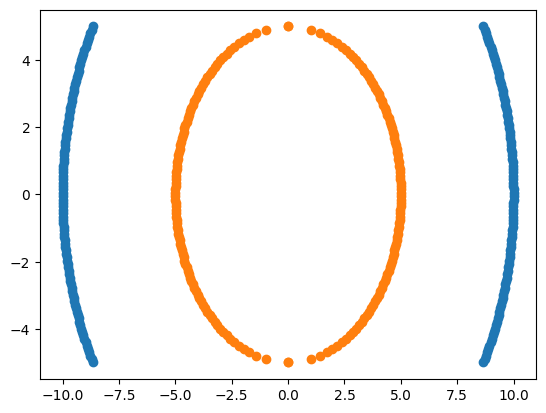

In [5]:
plt.scatter(y,x)
plt.scatter(y1, x1)

    Observe the DataPonits aren't seraparable 
    we can not create a linear line to separete the points

    so we will SVM kernels

In [9]:
# Label the Outer Datapoints ( Bleue ones ) as Zero 
# Label the inner Datapoints ( Orange ) as ones 

# Label outer ponits as 0 
# as Outer points are skeched from x, and y 
df1 = pd.DataFrame(np.vstack([y,x]).T, columns=["X1", "X2"]) 
df1["Y"] = 0

# Lable inner ponits as 1 
# as Outer points are skeched from x1, and y1 
df2 = pd.DataFrame(np.vstack([y1,x1]).T, columns=["X1", "X2"])
df2["Y"] = 1


# Make one df from both 
df = pd.concat([df1, df2])

df.head()

,X1,X2,Y
0,8.660254,-5.00000,0
1,8.717792,-4.89899,0
2,8.773790,-4.79798,0
3,8.828277,-4.69697,0
4,8.881281,-4.59596,0


In [10]:
df.tail()

,X1,X2,Y
195,-1.969049,-4.59596,1
196,-1.714198,-4.69697,1
197,-1.406908,-4.79798,1
198,-0.999949,-4.89899,1
199,-0.000000,-5.00000,1


___
# X and Y split
___

In [11]:
X = df.drop("Y", axis=1)
y = df["Y"]

___
# Train Test Split
___

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

### 

___
___

# Apply Polynomial Kernel  
     
     mathematically

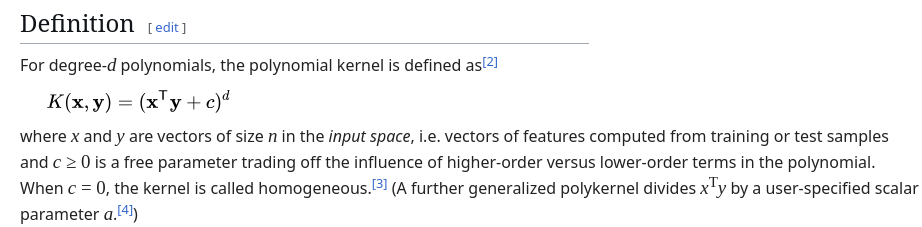

___
___

In [14]:
# we need to find component for poly nomial Kernal 
# X1,X2, X1_square, X2_qaure , X*X2

df["X1_square"] = df["X1"]**2
df["X2_square"] = df["X2"]**2
df["X1*X2"] = df["X1"] * df["X2"]

df.head()

,X1,X2,Y,X1_square,X2_square,X1*X2
0,8.660254,-5.00000,0,75.000000,25.000000,-43.301270
1,8.717792,-4.89899,0,75.999898,24.000102,-42.708375
2,8.773790,-4.79798,0,76.979390,23.020610,-42.096467
3,8.828277,-4.69697,0,77.938476,22.061524,-41.466150
4,8.881281,-4.59596,0,78.877155,21.122845,-40.818009


In [15]:
X = df.drop("Y", axis=1)
y = df["Y"]

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [ ]:
# now plot 
import plotly.express as px

fig = px.scatter_3d(df, x="X1" , y="X2", z="X1*X2", color='Y')
fig.show()

# Observe it still not clearly linear seraparable

In [ ]:
# now plot 
import plotly.express as px

fig = px.scatter_3d(df, x="X1_square" , y="X2_square", z="X1*X2", color='Y')
fig.show()

# Observe  Now it is linearly separable

___
# Model Training
___

In [19]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [ ]:
model = SVC(kernel="linear")

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(accuracy_score(y_test, y_pred))

# we got acuuracy as one 


1.0


    We Mannual implement the PolyNomial Kernel 

    but using sklearn we could just use **SVC(kernel = "poly" )** 
    and it will do all the implementation internally and gave us the same result 

In [ ]:
model = SVC(kernel="poly")

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(accuracy_score(y_test, y_pred))

# we got acuuracy as one  the ssame accuracy 


1.0


In [22]:
model = SVC(kernel="rbf")

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(accuracy_score(y_test, y_pred))

# we got acuuracy as one 


1.0
